In [ ]:
import sys, os # python module that handles filenames, paths, and directories
import numpy as np # a python library with tools that make it easy to work with matrices
import pandas as pd # a python library with tools for data analysis
import matplotlib.pyplot as plt # python plotting tools
import matplotlib.dates as mdates # for working with dates in python
import seaborn as sns # a python library for plotting
import datetime as dt # a python library for working with datetime objects
import scipy.stats  as stats # python library with tools for statistical analysis
import statsmodels.api as sm
import statsmodels.formula.api as smf
import itertools
import numpy as np
from statsmodels.stats.multitest import multipletests
from statsmodels.formula.api import ols
sys.path.append(os.path.abspath(os.path.join('..','..','..'))) # this points the script to the folder where your data is stored 

# To ensure anonymity, we excluded several mobile home entries from the dataset due to their potential identifiability. Therefore, the average values might be different with the publication. 

In [28]:
dfs=pd.read_csv("data.csv")
dfs.sample(3)

,dateTime,temperature,RH,sensor_id,month,hour,year,time,date,OutdoorIndoor,site_id,Park_Name,CoolingSystem
158417,2018-09-22 23:10:00,70.293,28.912,i15,9,23,2018,23:10:00,2018-09-22,i,15,Boulder Meadows,swamp cooler
36342,2018-08-19 13:50:00,68.706,50.280,i05,8,13,2018,13:50:00,2018-08-19,i,5,Mapleton Park,NaN
239954,2018-08-15 04:40:00,70.894,64.318,i21,8,4,2018,04:40:00,2018-08-15,i,21,Vista Village,NaN


In [ ]:
dfs['dateTime'] = pd.to_datetime(dfs['dateTime'])
dfs['Time_installed'] = pd.to_datetime(dfs['Time_installed'])
dfs['Date_retrieved'] = pd.to_datetime(dfs['Date_retrieved'])

In [10]:
dfs = dfs[(dfs['dateTime']>=dfs['Time_installed']) & (dfs['dateTime']<=dfs['Date_retrieved'])]

In [25]:
dfs['sensor_id'].unique()

array(['i02', 'i03', 'i05', 'i07', 'i09', 'i10', 'i11', 'i12', 'i13',
       'i14', 'i15', 'i16', 'i17', 'i18', 'i19', 'i20', 'i21', 'i22',
       'i23', 'i24', 'i26', 'i27', 'i28', 'o15', 'o18', 'o21'],
      dtype=object)

In [4]:
all_dfs = dfs

In [5]:
all_dfs.sample()

,dateTime,temperature,RH,sensor_id,month,hour,year,time,date,OutdoorIndoor,site_id,Park_Name,CoolingSystem
150603,2018-07-10 14:30:00,79.533,59.612,i12,7,14,2018,14:30:00,2018-07-10,i,12,Mapleton Park,swamp cooler


In [6]:
all_dfs['OutdoorIndoor'].unique()

array(['i', 'o'], dtype=object)

In [7]:
len(all_dfs)

437751

In [12]:
all_dfs['dateTime'].min()
all_dfs['Hour'] = all_dfs['dateTime'].dt.hour
all_dfs.rename(columns={'site_id':'location_id'},inplace=True)

In [13]:
def calculate_heat_index(temp_f, rh_percent):
    """
    Calculates the Heat Index (feels-like temperature) in Fahrenheit.

    Args:
        temp_f (float): Temperature in Fahrenheit.
        rh_percent (float): Relative humidity as a percentage.

    Returns:
        float: Heat Index in Fahrenheit.
    """
    heatindex = (
        -42.379 +
        2.04901523 * temp_f +
        10.14333127 * rh_percent -
        0.22475541 * temp_f * rh_percent -
        6.83783e-03 * temp_f**2 -
        5.481717e-02 * rh_percent**2 +
        1.22874e-03 * temp_f**2 * rh_percent +
        8.5282e-04 * temp_f * rh_percent**2 -
        1.99e-06 * temp_f**2 * rh_percent**2
    )
    return heatindex

# Example usage:
temp_fahrenheit = 86  # Assuming temperature is already in Fahrenheit
humidity_percent = 90
heat_index_fahrenheit = calculate_heat_index(temp_fahrenheit, humidity_percent)
print(f"Heat Index: {heat_index_fahrenheit:.2f} °F")


Heat Index: 105.29 °F


In [14]:
all_dfs['heat_index'] = all_dfs.apply(lambda row: calculate_heat_index(row['temperature'], row['RH']), axis=1)

In [15]:
all_dfs.loc[all_dfs['CoolingSystem'].isna(), 'CoolingSystem'] = 'No Cooling'
all_dfs.loc[all_dfs['sensor_id']=='i06','CoolingSystem'] = 'Passive Cooling'
all_dfs.loc[all_dfs['CoolingSystem']=='A/C', 'CoolingSystem'] = 'AC'
all_dfs.loc[all_dfs['CoolingSystem']=='None then swamp cooler from 7/25','CoolingSystem']= 'No Cooling'

In [ ]:

mask = (all_dfs['dateTime'] >= '2018-07-07 00:00:00') & (all_dfs['dateTime'] <= '2018-08-30 00:00:00')


In [17]:
all_dfs_mask = all_dfs.loc[mask]

In [18]:
all_dfs_mask.sample()

,dateTime,temperature,RH,sensor_id,month,hour,year,time,date,OutdoorIndoor,location_id,Park_Name,CoolingSystem,Hour,heat_index
109745,2018-08-08 09:50:00,70.894,60.051,i09,8,9,2018,09:50:00,2018-08-08,i,9,Mapleton Park,swamp cooler,9,75.924858


In [19]:
df_out = all_dfs_mask[all_dfs_mask['OutdoorIndoor'] == 'o']
df_in = all_dfs_mask[all_dfs_mask['OutdoorIndoor'] == 'i']
# out_dfs = all_dfs.loc[mask_out]
# in_dfs = all_dfs.loc[mask_in]


In [20]:
print(len(df_in['sensor_id'].unique()))
print(len(df_out['sensor_id'].unique()))

26
4


In [21]:
df_in.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202218 entries, 59 to 370580
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   dateTime       202218 non-null  datetime64[ns]
 1   temperature    202202 non-null  float64       
 2   RH             202202 non-null  float64       
 3   sensor_id      202218 non-null  object        
 4   month          202218 non-null  int64         
 5   hour           202218 non-null  int64         
 6   year           202218 non-null  int64         
 7   time           202218 non-null  object        
 8   date           202218 non-null  object        
 9   OutdoorIndoor  202218 non-null  object        
 10  location_id    202218 non-null  int64         
 11  Park_Name      202218 non-null  object        
 12  CoolingSystem  202218 non-null  object        
 13  Hour           202218 non-null  int32         
 14  heat_index     202202 non-null  float64       
dtypes: d

In [ ]:

dat = df_in[['temperature', 'CoolingSystem', 'sensor_id']].dropna().reset_index(drop=True)



res = smf.ols("temperature ~ C(CoolingSystem)", data=dat).fit(
    cov_type='cluster',
    cov_kwds={'groups': dat['sensor_id']}
)

# Example: make AC baseline
dat["CoolingSystem"] = pd.Categorical(
    dat["CoolingSystem"],
    categories=["AC", "swamp cooler", "No Cooling", "Passive Cooling"]
)

res_ac = smf.ols("temperature ~ C(CoolingSystem)", data=dat).fit(
    cov_type='cluster',
    cov_kwds={'groups': dat['sensor_id']}
)
print(res_ac.summary())


                            OLS Regression Results                            
Dep. Variable:            temperature   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     4.879
Date:                Wed, 18 Feb 2026   Prob (F-statistic):            0.00802
Time:                        12:29:30   Log-Likelihood:            -5.5222e+05
No. Observations:              184478   AIC:                         1.104e+06
Df Residuals:                  184474   BIC:                         1.104e+06
Df Model:                           3                                         
Covariance Type:              cluster                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [ ]:


# 1. Prep data
dat = df_in[['temperature', 'CoolingSystem', 'sensor_id']].dropna().copy()
dat['CoolingSystem'] = dat['CoolingSystem'].astype('category')

# 2. Fit base model once
base_formula = "temperature ~ C(CoolingSystem)"
res = smf.ols(base_formula, data=dat).fit(
    cov_type='cluster',
    cov_kwds={'groups': dat['sensor_id']}
)

# 3. Helper to refit with a chosen baseline & extract pairwise diffs vs baseline
def fit_with_baseline(baseline, dat):
    cats = list(dat['CoolingSystem'].cat.categories)
    # Put baseline first
    cats_releveled = [baseline] + [c for c in cats if c != baseline]
    dat = dat.copy()
    dat['CoolingSystem'] = dat['CoolingSystem'].cat.set_categories(cats_releveled, ordered=False)
    res_bl = smf.ols("temperature ~ C(CoolingSystem)", data=dat).fit(
        cov_type='cluster',
        cov_kwds={'groups': dat['sensor_id']}
    )
    return dat, res_bl

# 4. Collect all pairwise comparisons
pairs = list(itertools.combinations(dat['CoolingSystem'].cat.categories, 2))
rows = []

for g1, g2 in pairs:
    # Make g1 the baseline so the coefficient for g2 is (mean_g2 - mean_g1)
    dat_bl, res_bl = fit_with_baseline(g1, dat)

    # Find the exact parameter name for g2
    # It will look like C(CoolingSystem)[T.<g2>]
    param_name = None
    for name in res_bl.params.index:
        if f"[T.{g2}]" in name:
            param_name = name
            break
    if param_name is None:
        continue  # should not happen, but be safe

    coef = res_bl.params[param_name]
    se = res_bl.bse[param_name]
    pval = res_bl.pvalues[param_name]

    rows.append({
        "group1": g1,
        "group2": g2,
        "diff_mean": coef,          # mean(group2) - mean(group1)
        "se": se,
        "pval_raw": pval
    })

pairwise_df = pd.DataFrame(rows)

# 5. Optional: multiple-testing correction (e.g. Holm)
reject, pval_adj, _, _ = multipletests(pairwise_df["pval_raw"],
                                       alpha=0.05,
                                       method="holm")
pairwise_df["pval_adj"] = pval_adj
pairwise_df["significant_0.05_adj"] = reject

# 6. Nice printing
with pd.option_context("display.float_format", "{:0.4f}".format):
    print(pairwise_df)



            group1           group2  diff_mean     se  pval_raw  pval_adj  \
0               AC       No Cooling     1.3982 0.7351    0.0572    0.2287   
1               AC  Passive Cooling    -0.3884 0.5223    0.4571    0.4571   
2               AC     swamp cooler    -1.2136 0.7672    0.1137    0.3411   
3       No Cooling  Passive Cooling    -1.7866 0.5173    0.0006    0.0033   
4       No Cooling     swamp cooler    -2.6118 0.7638    0.0006    0.0033   
5  Passive Cooling     swamp cooler    -0.8252 0.5620    0.1420    0.3411   

   significant_0.05_adj  
0                 False  
1                 False  
2                 False  
3                  True  
4                  True  
5                 False  


c:\Users\mehdi\.conda\envs\UDA\Lib\site-packages\statsmodels\regression\linear_model.py:1885: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


In [29]:
avg_temp = df_in.groupby(['dateTime']).agg({'temperature':'mean'}).reset_index()
# avg_temp.rename(columns = {'temperature':'avg_indoor_temp'},inplace = True)
avg_temp['sensor_id'] = 'avg_indoor'
avg_temp['month'] = avg_temp['dateTime'].dt.month
avg_temp['hour'] = avg_temp['dateTime'].dt.hour
avg_temp['OutdoorIndoor'] = "i"
avg_temp['location_id'] = "avg_indoor"

avg_temp.sample()

,dateTime,temperature,sensor_id,month,hour,OutdoorIndoor,location_id
1623,2018-07-18 18:00:00,81.066647,avg_indoor,7,18,i,avg_indoor


In [30]:
df_in = pd.concat([df_in,avg_temp])

In [35]:
df_in['minute_of_day'] = df_in['dateTime'].dt.hour * 60 + df_in['dateTime'].dt.minute
df_out['minute_of_day'] = df_out['dateTime'].dt.hour * 60 + df_out['dateTime'].dt.minute


C:\Users\mp5160\AppData\Local\Temp\ipykernel_20712\3653152496.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_out['minute_of_day'] = df_out['dateTime'].dt.hour * 60 + df_out['dateTime'].dt.minute


In [37]:
df_in.groupby(['location_id', 'minute_of_day', 'OutdoorIndoor'],as_index=False).agg({'temperature':'mean','RH':'mean'})

,location_id,minute_of_day,OutdoorIndoor,temperature,RH
0,1,0,i,70.457500,55.966407
1,1,10,i,70.293642,56.105943
2,1,20,i,70.142981,56.112925
3,1,30,i,70.006075,56.354623
4,1,40,i,69.826132,56.735925
...,...,...,...,...,...
4033,avg_indoor,1390,i,76.103421,NaN
4034,avg_indoor,1400,i,75.990940,NaN
4035,avg_indoor,1410,i,75.878852,NaN
4036,avg_indoor,1420,i,75.766795,NaN


In [39]:
# df_mean = all_dfs.groupby(['location_id', 'minute_of_day', 'OutdoorIndoor'], as_index=False)['temperature','RH'].mean();
df_in_mean = df_in.groupby(['location_id', 'minute_of_day', 'OutdoorIndoor'],as_index=False).agg({'temperature':'mean','RH':'mean'})
# df_in_mean_all = df_in_mean.groupby(['minute_of_day']).agg({'temperature':'mean'}).reset_index();

df_out_mean = df_out.groupby(['location_id', 'minute_of_day', 'OutdoorIndoor'], as_index=False).agg({'temperature':'mean','RH':'mean'})
df_out_mean_all = df_out_mean.groupby(['minute_of_day']).agg({'temperature':'mean'}).reset_index();
df_out_mean_all.rename(columns = {'temperature':'temp_outdoor'},inplace = True)


In [41]:
max_Temp_out = df_out_mean_all['temp_outdoor'].max()
# max_temp_out = 82.39382222222221
df_out_mean_all.loc[df_out_mean_all['temp_outdoor']==max_Temp_out]
# minute_of_day for temp outdoor is 870

,minute_of_day,temp_outdoor
87,870,82.953978


In [42]:
# Finding the minute_of_day where each location hits the maximum temperature
max_temp_by_location = df_in_mean.loc[df_in_mean.groupby('location_id')['temperature'].idxmax()]

# Selecting only the required columns
df_thermal_lag = max_temp_by_location[['location_id', 'minute_of_day', 'temperature']]




In [43]:
df_thermal_lag

,location_id,minute_of_day,temperature
101,1,1010,75.977815
250,2,1060,81.309926
395,3,1070,76.700185
546,4,1140,75.983019
681,5,1050,81.997333
837,6,1170,79.327204
970,7,1060,81.246444
1121,8,1130,79.030426
1253,9,1010,78.993741
1387,10,910,88.267648


In [44]:
df_thermal_lag['thermal_lag'] = (df_thermal_lag['minute_of_day'] - 870)/60
df_thermal_lag.sample()

C:\Users\mp5160\AppData\Local\Temp\ipykernel_20712\384810095.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_thermal_lag['thermal_lag'] = (df_thermal_lag['minute_of_day'] - 870)/60


,location_id,minute_of_day,temperature,thermal_lag
1690,12,1060,78.953759,3.166667


In [45]:
df_thermal_lag['peak_time'] = df_thermal_lag['minute_of_day']/60

In [46]:
df_thermal_lag = df_thermal_lag.loc[df_thermal_lag['location_id']!='avg_indoor']

In [47]:
# looks like the site 10 and 24 act like an outlier
df_in_mean = df_in_mean.loc[~(df_in_mean['location_id'].isin([10,24]))]

## Average of temperature at indoor locations

In [48]:
df_in_mean['hour'] = (df_in_mean['minute_of_day'] / 60).astype('int')
df_out_mean_all['hour'] = (df_out_mean_all['minute_of_day'] / 60).astype('int')
df_in_mean

,location_id,minute_of_day,OutdoorIndoor,temperature,RH,hour
0,1,0,i,70.457500,55.966407,0
1,1,10,i,70.293642,56.105943,0
2,1,20,i,70.142981,56.112925,0
3,1,30,i,70.006075,56.354623,0
4,1,40,i,69.826132,56.735925,0
...,...,...,...,...,...,...
4033,avg_indoor,1390,i,76.103421,NaN,23
4034,avg_indoor,1400,i,75.990940,NaN,23
4035,avg_indoor,1410,i,75.878852,NaN,23
4036,avg_indoor,1420,i,75.766795,NaN,23


In [ ]:
filtered_df_in

In [ ]:
df_thermal_lag.sample()

In [ ]:
df_thermal_lag = df_thermal_lag.loc[df_thermal_lag['thermal_lag']>0]
df_thermal_lag

ValueError: Could not interpret value `temperature` for `y`. An entry with this name does not appear in `data`.

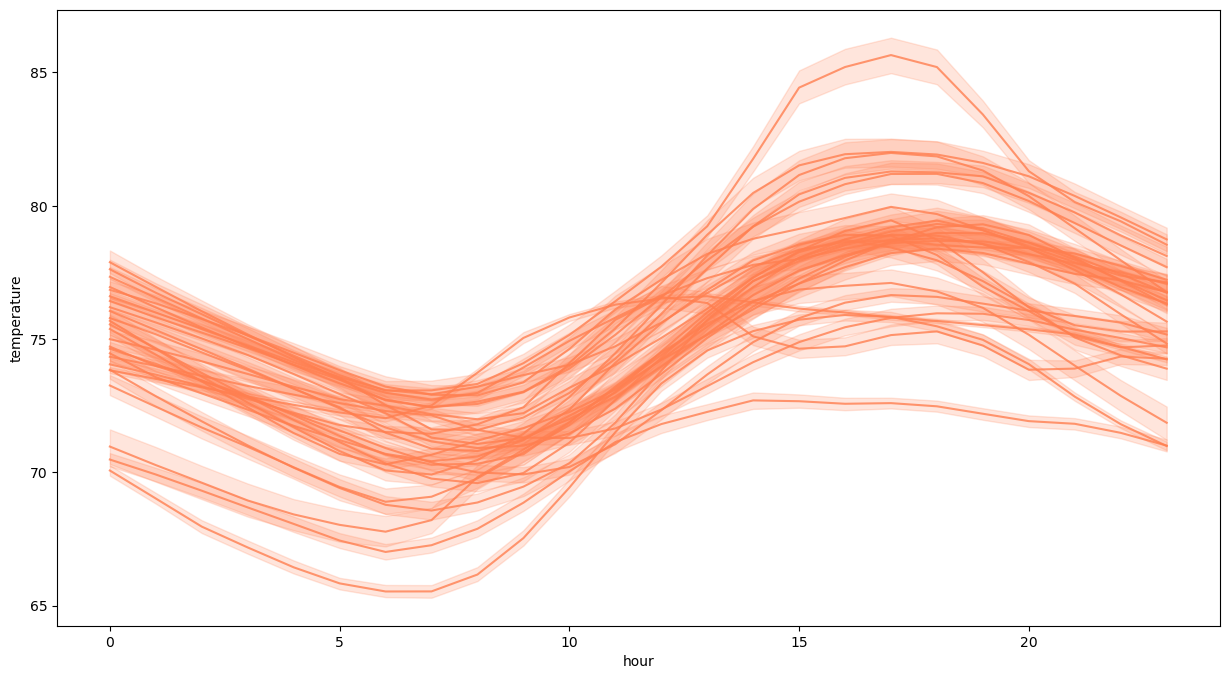

In [51]:


# Filtered dataframe
filtered_df_in = df_in.loc[~df_in['location_id'].isin([10, 24,'avg_indoor'])]

# Creating a gray palette with the correct number of colors
gray_palette = sns.color_palette(['coral'] * filtered_df_in['location_id'].nunique())

plt.figure(figsize=(15, 8))

# Plotting the first dataset with all lines in gray
sns.lineplot(data=filtered_df_in, x='hour', y='temperature', hue='location_id', palette=gray_palette, alpha=0.8, legend=False)

# Plotting the second dataset with custom label
sns.lineplot(data=df_out_mean_all, x='hour', y='temperature', color='black', label='Outdoor Temperature', legend=False)

# Adding thin and faint grid lines
plt.grid(True, which='both', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)
plt.minorticks_on()  # Enable minor ticks
plt.grid(which='minor', linestyle=':', linewidth=0.5, color='grey', alpha=0.5)  # Minor grid lines

# Enlarging the labels
plt.xlabel('Hours', fontsize=16)
plt.ylabel('Temperature (F)', fontsize=16)
# plt.title('Temperature Over Time', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Adding a custom legend
import matplotlib.patches as mpatches

indoor_patch = mpatches.Patch(color='coral', label='Indoor Temperatures')
outdoor_patch = mpatches.Patch(color='black', label='Outdoor Temperatures')
plt.legend(handles=[indoor_patch, outdoor_patch], fontsize=14, title='Legend')
plt.setp(plt.gca().get_legend().get_title(), fontsize=14)  # Set the legend title font size




In [ ]:
dictVals = {}
for location in df_in_mean['location_id'].unique()[:-1]:
    th_df = df_in_mean.loc[df_in_mean['location_id']==location]
    val = th_df.loc[th_df['temperature']==th_df['temperature'].max()]['minute_of_day'].values[0]
    dictVals[location] = val


In [ ]:
df_lags['hour_formatted'] = df_lags['hour'].apply(lambda x: f'{int(x):02d}:{int((x - int(x)) * 60):02d}')
df_lags

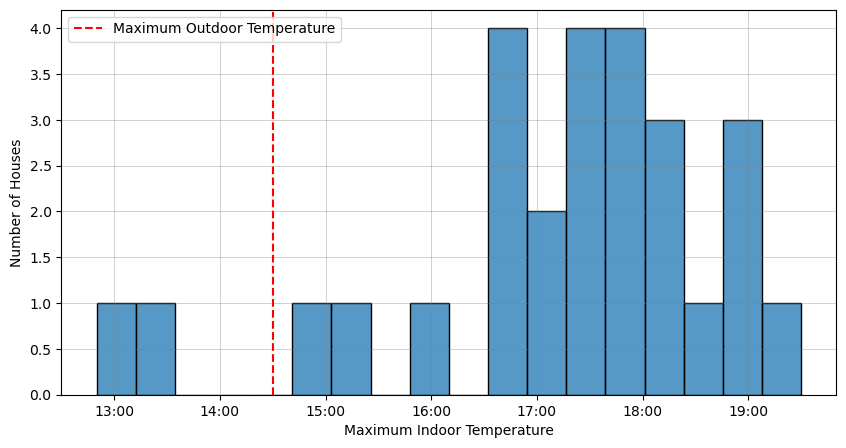

In [52]:
# this is the second iteration of the thermal lag code. use this one. 
plt.figure(figsize=(10, 5))
plt.grid(True, which='both', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)

# df_lags = pd.DataFrame(dictVals.items(), columns=['location_id', 'time_of_day'])
# df_lags['hour'] = df_lags['time_of_day']/60
ticks = [13,14,15,16,17,18,19]
labels = ['13:00','14:00', '15:00', '16:00', '17:00', '18:00','19:00']
sns.histplot(data = df_thermal_lag,x='peak_time',bins = 18)
plt.xticks(ticks=ticks, labels=labels)
# Use the renamed functions
plt.xlabel('Maximum Indoor Temperature')
plt.ylabel('Number of Houses')

plt.axvline(x=14.5, color='red', linestyle='--', label='Maximum Outdoor Temperature')
plt.legend(loc='upper left')

[None]

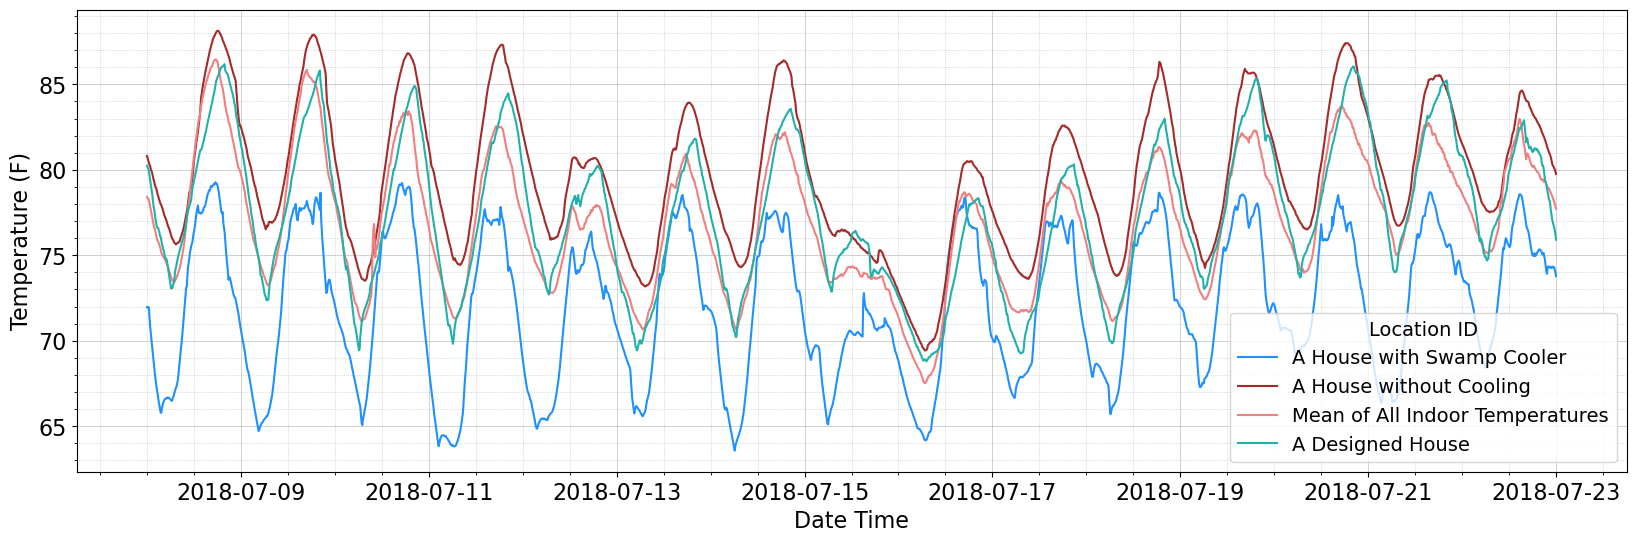

In [74]:
start_date = '2018-07-08'
end_date = '2018-07-23'
# [ 1,  2,  3,  5,  6,  7,  8,  9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 27]
lst_locations =[1,6, 7,"avg_indoor"]
thisDF = df_in.loc[(df_in['dateTime']>=start_date)
                   & (df_in['dateTime']<=end_date)
                   & (df_in['location_id'].isin(lst_locations))]

# Your existing code
plt.figure(figsize=(20, 6))
# sns.lineplot(data=thisDF, x='dateTime', y='temperature', hue='location_id', palette=sns.color_palette("hls", 3)[::-1])


sns.lineplot(data=thisDF.loc[thisDF['location_id']==1], x='dateTime', y='temperature', color = 'dodgerblue', label = 'A House with Swamp Cooler')
sns.lineplot(data=thisDF.loc[thisDF['location_id']==7], x='dateTime', y='temperature', color = 'brown', label = 'A House without Cooling')
sns.lineplot(data=thisDF.loc[thisDF['location_id']=='avg_indoor'], x='dateTime', y='temperature', color = 'lightcoral', label = 'Mean of All Indoor Temperatures')
sns.lineplot(data=thisDF.loc[thisDF['location_id']==6], x='dateTime', y='temperature', color = 'lightseagreen', label = 'A Designed House')




# Adding thin and faint grid lines
plt.grid(True, which='both', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)
plt.minorticks_on()  # Enable minor ticks
plt.grid(which='minor', linestyle=':', linewidth=0.5, color='grey', alpha=0.5)  # Minor grid lines


# Enlarging the labels
plt.xlabel('Date Time', fontsize=16)
plt.ylabel('Temperature (F)', fontsize=16)
# plt.title('Temperature Over Time', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.legend(fontsize=12)

# Enlarging the legend font size and setting the legend title
legend = plt.legend(fontsize=14, title='Location ID')
plt.setp(legend.get_title(), fontsize=14)  # Set the legend title font size
# Display the plot


[None]

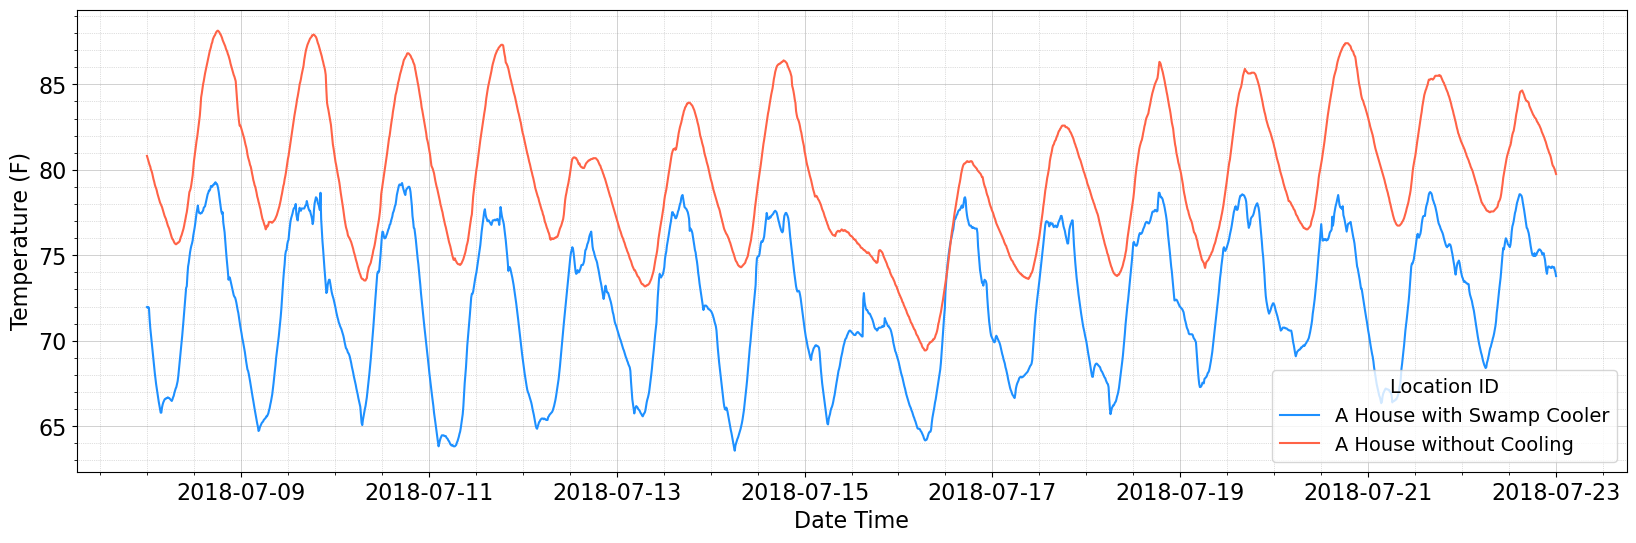

In [75]:
start_date = '2018-07-08'
end_date = '2018-07-23'
# [ 1,  2,  3,  5,  6,  7,  8,  9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 27]
lst_locations =[1,  7]
thisDF = df_in.loc[(df_in['dateTime']>=start_date)
                   & (df_in['dateTime']<=end_date)
                   & (df_in['location_id'].isin(lst_locations))]


# Your existing code
plt.figure(figsize=(20, 6))
# sns.lineplot(data=thisDF, x='dateTime', y='temperature', hue='location_id', palette=sns.color_palette("hls", 2)[::-1])


sns.lineplot(data=thisDF.loc[thisDF['location_id']==1], x='dateTime', y='temperature', color = 'dodgerblue', label = 'A House with Swamp Cooler')
sns.lineplot(data=thisDF.loc[thisDF['location_id']==7], x='dateTime', y='temperature', color = 'tomato', label = 'A House without Cooling')

# Adding thin and faint grid lines
plt.grid(True, which='both', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)
plt.minorticks_on()  # Enable minor ticks
plt.grid(which='minor', linestyle=':', linewidth=0.5, color='grey', alpha=0.5)  # Minor grid lines


# Enlarging the labels
plt.xlabel('Date Time', fontsize=16)
plt.ylabel('Temperature (F)', fontsize=16)
# plt.title('Temperature Over Time', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.legend(fontsize=12)

# Enlarging the legend font size and setting the legend title
legend = plt.legend(fontsize=14, title='Location ID')
plt.setp(legend.get_title(), fontsize=14)  # Set the legend title font size
# Display the plot


[None]

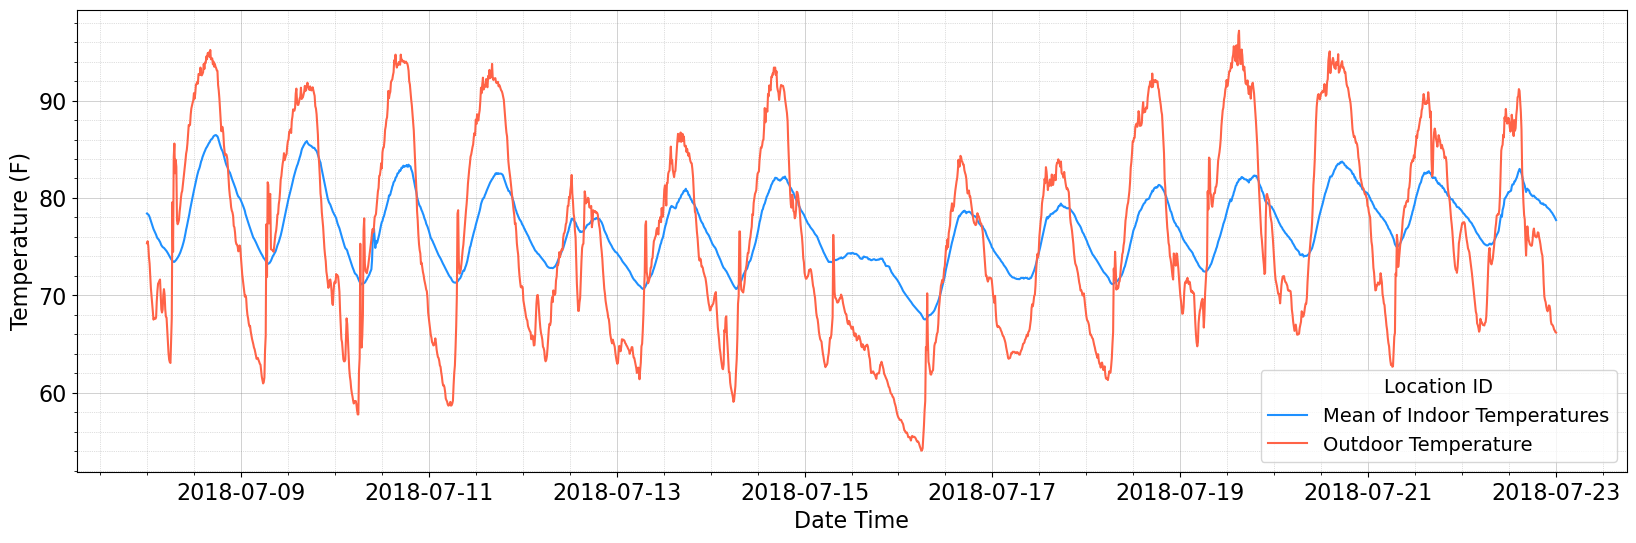

In [76]:
start_date = '2018-07-08'
end_date = '2018-07-23'
# [ 1,  2,  3,  5,  6,  7,  8,  9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 27]
lst_locations =['avg_indoor']
thisDF_in = df_in.loc[(df_in['dateTime']>=start_date)
                   & (df_in['dateTime']<=end_date)
                   & (df_in['location_id'].isin(lst_locations))]

thisDF_out = df_out.loc[(df_out['dateTime']>=start_date)
                   & (df_out['dateTime']<=end_date)
                   & (df_out['location_id']==6)]

plt.figure(figsize=(20, 6))
sns.lineplot(data = thisDF_in, x = 'dateTime',y ='temperature',color = 'dodgerblue',label = "Mean of Indoor Temperatures")
sns.lineplot(data = thisDF_out, x = 'dateTime',y ='temperature',color = 'tomato',label = "Outdoor Temperature")

# Adding thin and faint grid lines
plt.grid(True, which='both', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)
plt.minorticks_on()  # Enable minor ticks
plt.grid(which='minor', linestyle=':', linewidth=0.5, color='grey', alpha=0.5)  # Minor grid lines


# Enlarging the labels
plt.xlabel('Date Time', fontsize=16)
plt.ylabel('Temperature (F)', fontsize=16)
# plt.title('Temperature Over Time', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Enlarging the legend font size and setting the legend title
legend = plt.legend(fontsize=14, title='Location ID')
plt.setp(legend.get_title(), fontsize=14)  # Set the legend title font size
# Display the plot

### for indoor and outdoor comparisons

<Axes: xlabel='dateTime', ylabel='temperature'>

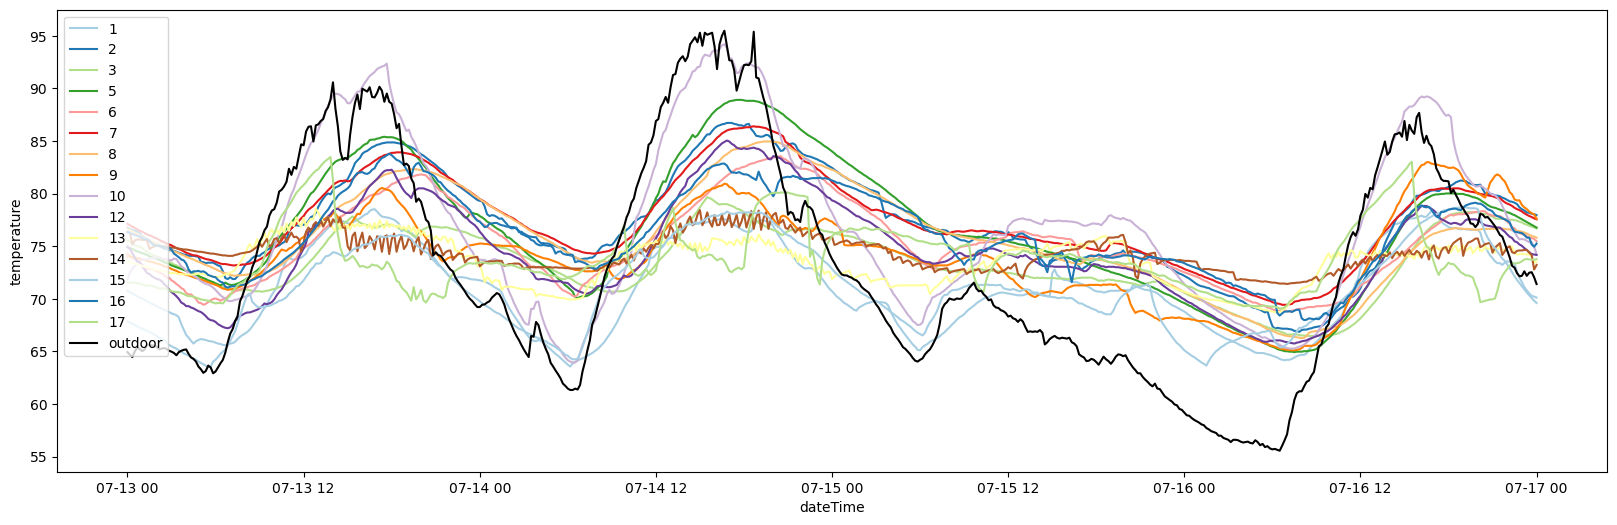

In [77]:
start_date = '2018-07-13'
end_date = '2018-07-17'
# [ 1,  2,  3,  5,  6,  7,  8,  9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 27]
lst_locations =[ 1,  2,  3,  5,  6,  7,  8,  9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 27]
thisDF_in = df_in.loc[(df_in['dateTime']>=start_date)
                   & (df_in['dateTime']<=end_date)
                   & (df_in['location_id'].isin(lst_locations))]

thisDF_out = df_out.loc[(df_out['dateTime']>=start_date)
                   & (df_out['dateTime']<=end_date)
                   & (df_out['location_id'].isin([1]))]

plt.figure(figsize=(20, 6))

# Create a palette with a sufficient number of colors
num_locations = thisDF_in['location_id'].nunique()
palette = sns.color_palette("Paired", num_locations)  # Adjust this to any palette if "Paired" is not preferred

# Plotting
sns.lineplot(data=thisDF_in, x='dateTime', y='temperature', hue='location_id', palette=palette)

sns.lineplot(data = thisDF_out, x = 'dateTime',y ='temperature',color='black',label='outdoor')

<Axes: xlabel='dateTime', ylabel='temperature'>

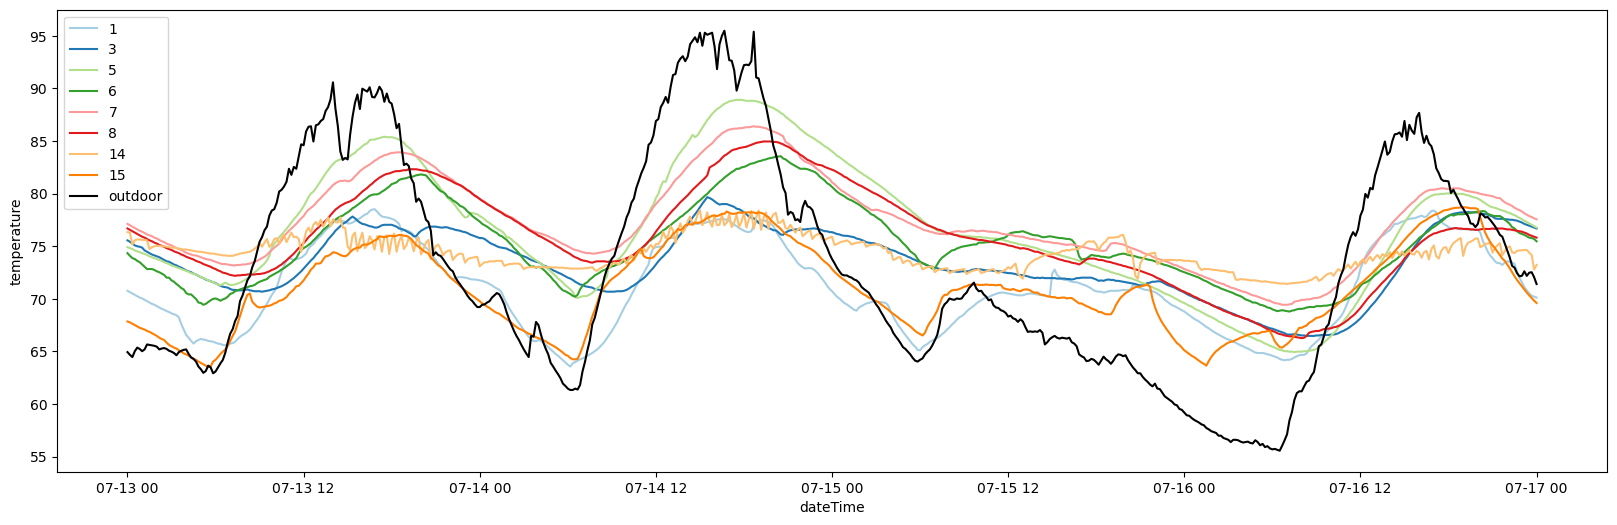

In [78]:
start_date = '2018-07-13'
end_date = '2018-07-17'
# [ 1,  2,  3,  5,  6,  7,  8,  9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 27]
lst_locations =[ 1,  3,5, 6, 8, 15, 14 , 7]
thisDF_in = df_in.loc[(df_in['dateTime']>=start_date)
                   & (df_in['dateTime']<=end_date)
                   & (df_in['location_id'].isin(lst_locations))]

thisDF_out = df_out.loc[(df_out['dateTime']>=start_date)
                   & (df_out['dateTime']<=end_date)
                   & (df_out['location_id'].isin([1]))]

plt.figure(figsize=(20, 6))

# Create a palette with a sufficient number of colors
num_locations = thisDF_in['location_id'].nunique()
palette = sns.color_palette("Paired", num_locations)  # Adjust this to any palette if "Paired" is not preferred

# Plotting
sns.lineplot(data=thisDF_in, x='dateTime', y='temperature', hue='location_id', palette=palette)

sns.lineplot(data = thisDF_out, x = 'dateTime',y ='temperature',color='black',label='outdoor')

[None]

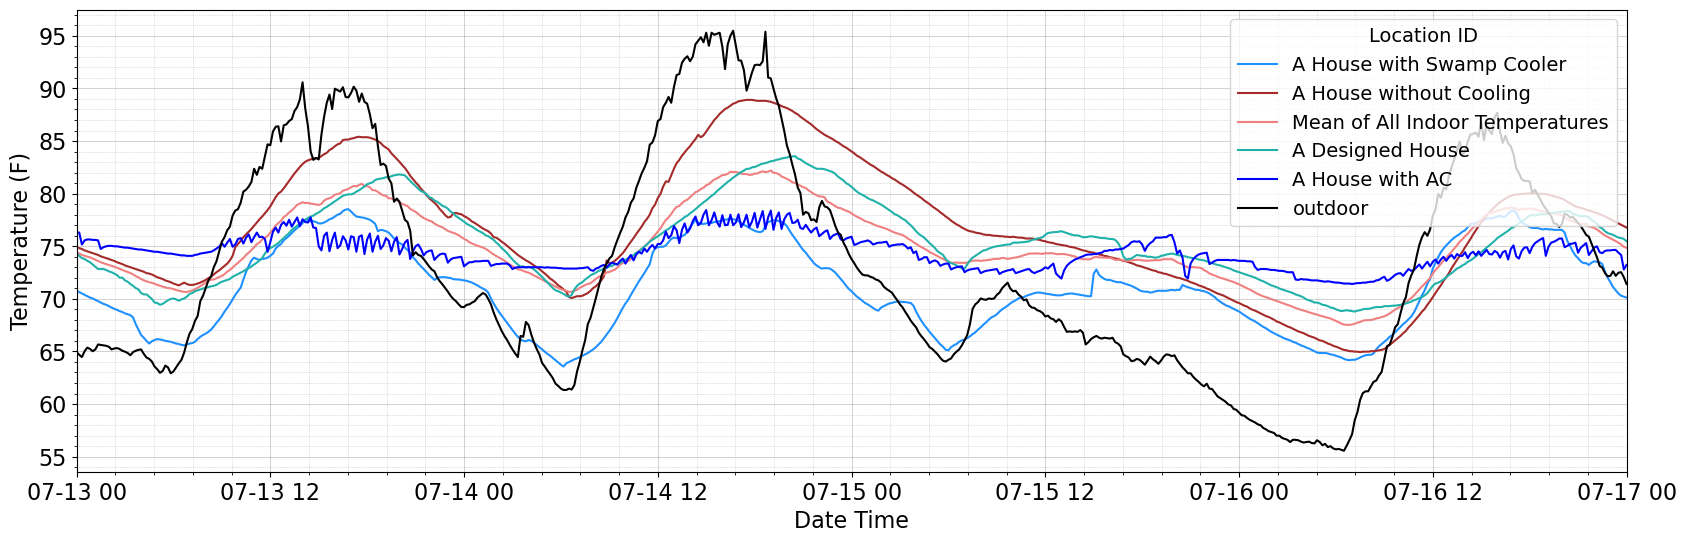

In [122]:
start_date = '2018-07-13'
end_date = '2018-07-17'


# start_date = '2018-08-22'
# end_date = '2018-08-28'

# [ 1,  2,  3,  5,  6,  7,  8,  9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 27]
lst_locations =[ 1,   6,7, 14 , 5,'avg_indoor']
thisDF_in = df_in.loc[(df_in['dateTime']>=start_date)
                   & (df_in['dateTime']<=end_date)
                   & (df_in['location_id'].isin(lst_locations))]

thisDF_out = df_out.loc[(df_out['dateTime']>=start_date)
                   & (df_out['dateTime']<=end_date)
                   & (df_out['location_id'].isin([1]))]

plt.figure(figsize=(20, 6))

# Create a palette with a sufficient number of colors
num_locations = thisDF_in['location_id'].nunique()
palette = sns.color_palette("Paired", num_locations)  # Adjust this to any palette if "Paired" is not preferred

# Plotting
sns.lineplot(data=thisDF_in.loc[thisDF_in['location_id']==1], x='dateTime', y='temperature', color = 'dodgerblue', label = 'A House with Swamp Cooler')
sns.lineplot(data=thisDF_in.loc[thisDF_in['location_id']==5], x='dateTime', y='temperature', color = 'brown', label = 'A House without Cooling')
sns.lineplot(data=thisDF_in.loc[thisDF_in['location_id']=='avg_indoor'], x='dateTime', y='temperature', color = 'lightcoral', label = 'Mean of All Indoor Temperatures')
sns.lineplot(data=thisDF_in.loc[thisDF_in['location_id']==6], x='dateTime', y='temperature', color = 'lightseagreen', label = 'A Designed House')
sns.lineplot(data=thisDF_in.loc[thisDF_in['location_id']==14], x='dateTime', y='temperature', color = 'blue', label = 'A House with AC')


# sns.lineplot(data=thisDF_in, x='dateTime', y='temperature', hue='location_id', palette=palette)

sns.lineplot(data = thisDF_out, x = 'dateTime',y ='temperature',color='black',label='outdoor')
# Adding thin and faint grid lines
plt.grid(True, which='both', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)
plt.minorticks_on()  # Enable minor ticks
plt.grid(which='minor', linestyle=':', linewidth=0.5, color='grey', alpha=0.5)  # Minor grid lines


# Enlarging the labels
plt.xlabel('Date Time', fontsize=16)
plt.ylabel('Temperature (F)', fontsize=16)
# plt.title('Temperature Over Time', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

start_date_lim = pd.to_datetime(start_date) 
end_date_lim = pd.to_datetime(end_date)
plt.xlim(start_date_lim, end_date_lim)

# Enlarging the legend font size and setting the legend title
legend = plt.legend(fontsize=14, title='Location ID')
plt.setp(legend.get_title(), fontsize=14)  # Set the legend title font size

[None]

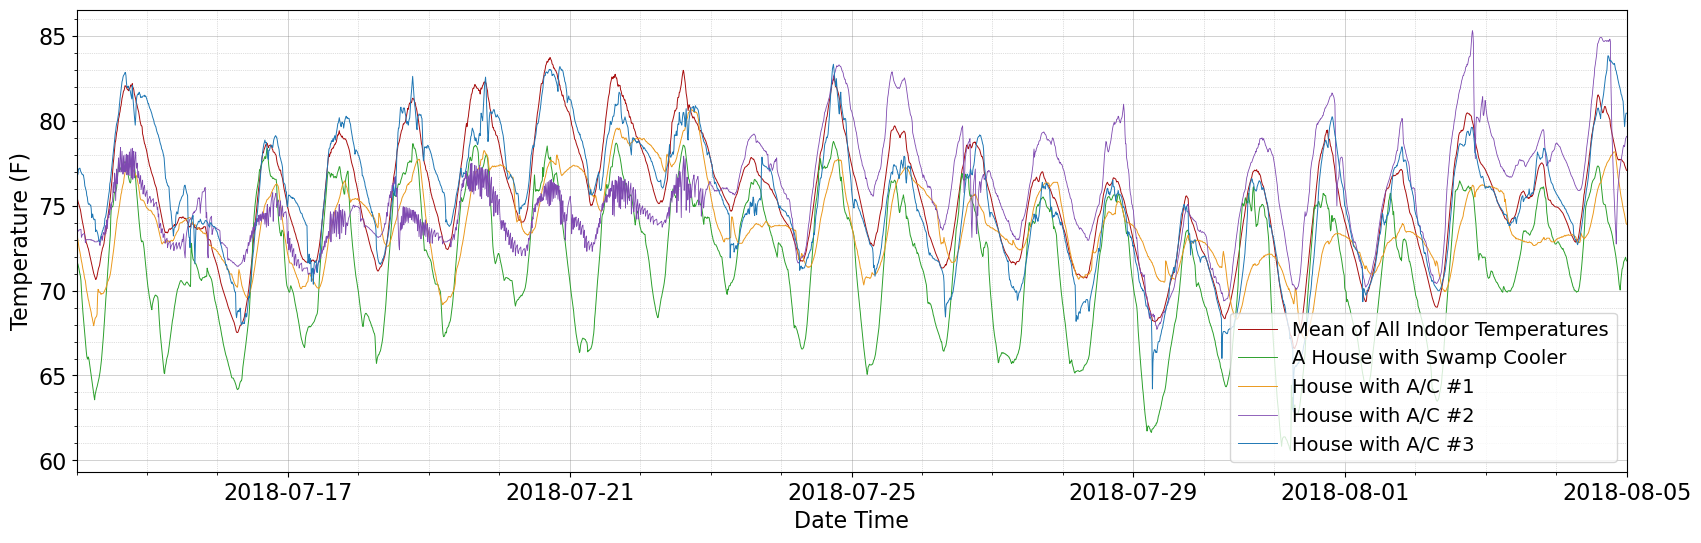

In [125]:
start_date = '2018-07-14'
end_date = '2018-08-05'

# start_date = '2018-08-22'
# end_date = '2018-08-28'

# [ 1,  2,  3,  5,  6,  7,  8,  9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 27]
lst_locations =[ 1, 4, 14,16,18,'avg_indoor']
thisDF_in = df_in.loc[(df_in['dateTime']>=start_date)
                   & (df_in['dateTime']<=end_date)
                   & (df_in['location_id'].isin(lst_locations))]

thisDF_out = df_out.loc[(df_out['dateTime']>=start_date)
                   & (df_out['dateTime']<=end_date)
                   & (df_out['location_id'].isin([1]))]

plt.figure(figsize=(20, 6))

# Create a palette with a sufficient number of colors
num_locations = thisDF_in['location_id'].nunique()
palette = sns.color_palette("Paired", num_locations)  # Adjust this to any palette if "Paired" is not preferred

# Plotting
sns.lineplot(data=thisDF_in.loc[thisDF_in['location_id']=='avg_indoor'], x='dateTime', y='temperature', color = "#a80e0e", label = 'Mean of All Indoor Temperatures',linewidth=0.7)
sns.lineplot(data=thisDF_in.loc[thisDF_in['location_id']==1], x='dateTime', y='temperature', color = '#2ca02c', label = 'A House with Swamp Cooler',linewidth=0.7)
sns.lineplot(data=thisDF_in.loc[thisDF_in['location_id']==4], x='dateTime', y='temperature', color = "#eb991d", label = 'House with A/C #1',linewidth=0.7)
sns.lineplot(data=thisDF_in.loc[thisDF_in['location_id']==14], x='dateTime', y='temperature', color = "#7e49b0", label = 'House with A/C #2',linewidth=0.6)
sns.lineplot(data=thisDF_in.loc[thisDF_in['location_id']==16], x='dateTime', y='temperature', color = '#1f77b4', label = 'House with A/C #3',linewidth=0.7)
# sns.lineplot(data=thisDF_in.loc[thisDF_in['location_id']==18], x='dateTime', y='temperature', color = 'blue', label = 'AC4',linewidth=0.4)


# sns.lineplot(data=thisDF_in, x='dateTime', y='temperature', hue='location_id', palette=palette)

# sns.lineplot(data = thisDF_out, x = 'dateTime',y ='temperature',color='black',label='outdoor',linewidth=0.4)
# Adding thin and faint grid lines
plt.grid(True, which='both', linestyle='-', linewidth=0.5, color='grey', alpha=0.5)
plt.minorticks_on()  # Enable minor ticks
plt.grid(which='minor', linestyle=':', linewidth=0.5, color='grey', alpha=0.5)  # Minor grid lines


# Enlarging the labels
plt.xlabel('Date Time', fontsize=16)
plt.ylabel('Temperature (F)', fontsize=16)
# plt.title('Temperature Over Time', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

start_date_lim = pd.to_datetime(start_date) 
end_date_lim = pd.to_datetime(end_date)
plt.xlim(start_date_lim, end_date_lim)

# Enlarging the legend font size and setting the legend title
legend = plt.legend(fontsize=14,loc='lower right')
plt.setp(legend.get_title(), fontsize=14)  # Set the legend title font size